# 🔬 Guarded Scan Report — Storage Ring × Beamline

Visual report for an HDF5 file produced by **`guarded_scan.py`**.

The notebook reads one `scan_*.h5`, figures out *what happened during the scan*,
and renders it accordingly:

| outcome | how it looks |
|---|---|
| ✅ **complete** — all projections acquired, beam healthy | clean green plots |
| ⏸️ **beam-loss pause** — beam dropped below the 50 mA gate, scan paused then resumed | amber, the pause shaded on the time-series |
| 💀 **vacuum-burst abort** — an interlock fired and `take_until` killed the scan | all red, skulls ☠, the abort point marked |

Orbit drift (frames with `|orbit_x| > 55 µm`) is flagged on top of any outcome.

> **Deps:** `pip install h5py numpy matplotlib`


In [6]:
import glob, os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Physical thresholds — must match demo/synchrotron-beamline/facility.py
ORBIT_ALARM      = 55.0   # µm  — |orbit_x| above this flags low quality
MIN_BEAM_CURRENT = 50.0   # mA  — health gate; below this the scan pauses

# --- choose the file -------------------------------------------------------
# Set SCAN_FILE explicitly, or leave None to pick the newest scan_*.h5 here.
SCAN_FILE = None
if SCAN_FILE is None:
    candidates = sorted(glob.glob("scan_*.h5"), key=os.path.getmtime)
    assert candidates, "No scan_*.h5 found in this directory — set SCAN_FILE."
    SCAN_FILE = candidates[-1]
print("Reading:", SCAN_FILE)


Reading: scan_20260608_232238.h5


## 1 · Load & classify

Unwritten rows are left zero-filled by the writer, so a frame counts as
*acquired* only when its `timestamp > 0`. A genuine **pause** is distinguished
from an ordinary startup stall by the **ring current collapsing toward the
50 mA gate** at the gap — not merely by the gap's length.

In [7]:
def load(path):
    with h5py.File(path, "r") as f:
        a = f["projections"][:]
        attrs = dict(f.attrs)
    valid = np.sort(a[a["timestamp"] > 0], order="proj_index")
    return valid, attrs

def analyze(valid, attrs):
    n_total = int(attrs.get("num_projections", len(valid)))
    n = len(valid)
    t = valid["timestamp"] - valid["timestamp"][0] if n else np.array([])
    gaps = np.diff(t) if n > 1 else np.array([])
    med = float(np.median(gaps)) if len(gaps) else 0.0
    pause_i = int(np.argmax(gaps)) if len(gaps) else -1
    max_gap = float(gaps[pause_i]) if len(gaps) else 0.0
    completed = n >= n_total
    # large gap AND current diving toward the gate => real beam-loss pause
    big_gap = bool(len(gaps)) and max_gap > max(4 * med, 3.0)
    cur_at_gap = (min(valid["ring_current"][pause_i],
                      valid["ring_current"][pause_i + 1])
                  if big_gap else np.inf)
    beam_dipped = cur_at_gap <= 1.2 * MIN_BEAM_CURRENT
    paused = completed and big_gap and beam_dipped
    drift = bool((~valid["quality_ok"]).any()) if n else False
    status = "aborted" if not completed else ("paused" if paused else "complete")
    return dict(n=n, n_total=n_total, t=t, gaps=gaps, med=med, pause_i=pause_i,
                max_gap=max_gap, completed=completed, paused=paused,
                drift=drift, status=status)

valid, attrs = load(SCAN_FILE)
A = analyze(valid, attrs)
print(f"status   : {A['status'].upper()}")
print(f"frames   : {A['n']}/{A['n_total']}")
print(f"orbit drift flagged : {A['drift']}")
if A['status'] == 'paused':
    print(f"pause    : {A['max_gap']:.1f}s")


status   : COMPLETE
frames   : 36/36
orbit drift flagged : True


## 2 · Status banner

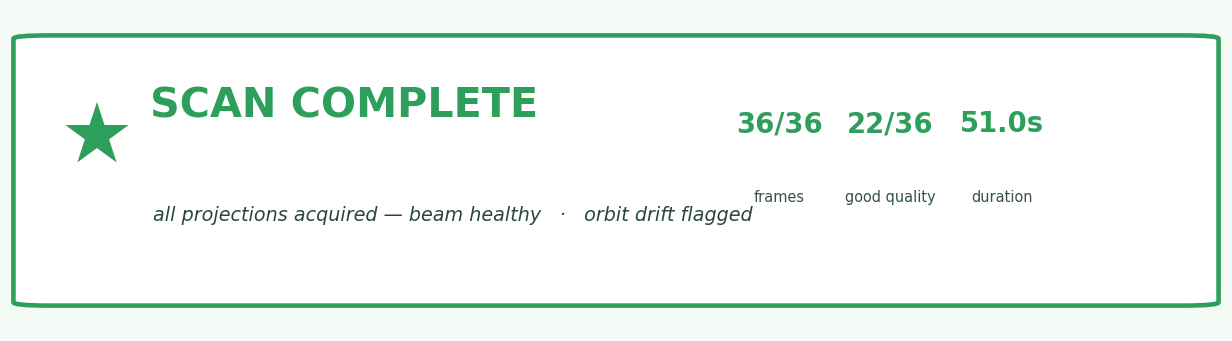

In [8]:
THEME = {
    "complete": dict(accent="#2e9e5b", accent2="#1f6f43", bg="#f4faf6",
                     panel="#ffffff", fg="#143324", grid="#d4e8dc",
                     glyph="\u2605", title="SCAN COMPLETE",
                     sub="all projections acquired \u2014 beam healthy"),
    "paused":   dict(accent="#e8902a", accent2="#b8650f", bg="#fdf7ec",
                     panel="#ffffff", fg="#4a2f06", grid="#f0e0c4",
                     glyph="", title="BEAM-LOSS PAUSE",
                     sub="scan paused on beam loss, then resumed"),
    "aborted":  dict(accent="#ff4d3d", accent2="#a11409", bg="#1a0a0a",
                     panel="#2a0f0f", fg="#ffd9d4", grid="#5a1a14",
                     glyph="\u2620", title="SCAN ABORTED",
                     sub="VACUUM BURST \u2014 interlock fired"),
}

def apply_style(th):
    plt.rcParams.update({
        "figure.facecolor": th["bg"], "axes.facecolor": th["panel"],
        "axes.edgecolor": th["grid"], "axes.labelcolor": th["fg"],
        "text.color": th["fg"], "xtick.color": th["fg"], "ytick.color": th["fg"],
        "axes.titlecolor": th["fg"], "grid.color": th["grid"],
        "font.size": 11, "axes.grid": True, "grid.alpha": 0.5,
        "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
    })

th = THEME[A["status"]]
apply_style(th)

fig = plt.figure(figsize=(11, 2.9))
fig.patch.set_facecolor(th["bg"])
ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off")
ax.add_patch(FancyBboxPatch((0.012, 0.08), 0.976, 0.84,
    boxstyle="round,pad=0.01,rounding_size=0.03", mutation_aspect=0.35,
    fc=th["panel"], ec=th["accent"], lw=3, transform=ax.transAxes))

# icon: drawn pause bars, or a glyph
if A["status"] == "paused":
    for bx in (0.040, 0.064):
        ax.add_patch(FancyBboxPatch((bx, 0.45), 0.014, 0.30,
            boxstyle="round,pad=0.002,rounding_size=0.01", mutation_aspect=0.4,
            fc=th["accent"], ec="none", transform=ax.transAxes))
else:
    ax.text(0.040, 0.60, th["glyph"], fontsize=54, color=th["accent"],
            va="center", ha="left")

ax.text(0.115, 0.70, th["title"], fontsize=27, fontweight="bold",
        color=th["accent"], va="center")
sub = th["sub"]
if A["status"] == "aborted":
    sub = " ".join(["\u2620"] * 4) + "   " + sub
if A["drift"] and A["status"] != "aborted":
    sub += "   \u00b7   orbit drift flagged"
ax.text(0.117, 0.36, sub, fontsize=12.5, color=th["fg"], va="center",
        style="italic", alpha=0.9)

good = int(valid["quality_ok"].sum()) if A["n"] else 0
dur = float(A["t"][-1]) if A["n"] else 0.0
if A["status"] == "aborted":
    last = valid[-1] if A["n"] else None
    chips = [("acquired", f"{A['n']}/{A['n_total']}"),
             ("lost", f"{A['n_total'] - A['n']}"),
             ("ring@abort", f"{last['ring_current']:.0f}mA" if last is not None else "-"),
             ("orbit@abort", f"{last['orbit_x']:+.0f}\u00b5m" if last is not None else "-")]
else:
    chips = [("frames", f"{A['n']}/{A['n_total']}"),
             ("good quality", f"{good}/{A['n']}"),
             ("duration", f"{dur:.1f}s")]
    if A["status"] == "paused":
        chips.append(("pause", f"{A['max_gap']:.1f}s"))

x0, dx = 0.635, 0.092
for k, (label, val) in enumerate(chips):
    x = x0 + k * dx
    ax.text(x, 0.62, val, fontsize=18, fontweight="bold", color=th["accent"], ha="center")
    ax.text(x, 0.40, label, fontsize=9.5, color=th["fg"], ha="center", alpha=0.85)

plt.show()


## 3 · Detail dashboard

Four views, themed by outcome:

- **Counts vs angle** — the tomography signal; drift frames in red.
- **Ring current vs time** — the 50 mA gate, the shaded pause, or the ☠ abort point.
- **Orbit X vs angle** — the ±55 µm quality band; drift frames marked ✗.
- **Acquisition timeline** — frame index vs time; the pause plateau or the lost-frames band.

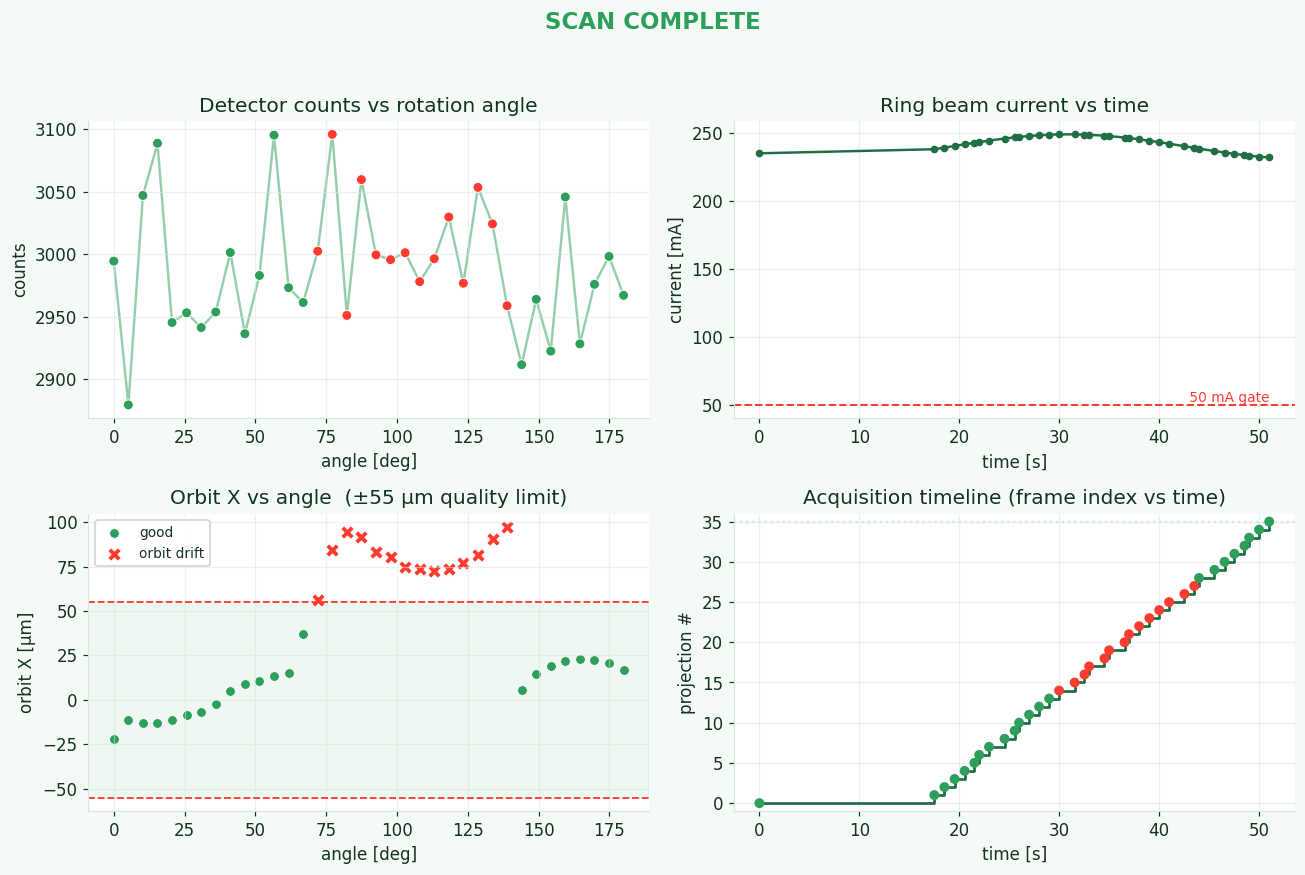

In [9]:
n = A["n"]; t = A["t"]
ang = valid["angle"]; cnt = valid["counts"]
cur = valid["ring_current"]; orb = valid["orbit_x"]; q = valid["quality_ok"]
BAD = "#ff3b30"

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor(th["bg"])

# 1 — counts vs angle
ax1.plot(ang, cnt, "-", color=th["accent"], lw=1.6, alpha=0.5, zorder=1)
ax1.scatter(ang, cnt, c=np.where(q, th["accent"], BAD), s=42, zorder=3,
            edgecolor=th["panel"], lw=0.6)
ax1.set_title("Detector counts vs rotation angle")
ax1.set_xlabel("angle [deg]"); ax1.set_ylabel("counts")

# 2 — ring current vs time
ax2.plot(t, cur, "-o", color=th["accent2"], ms=4, lw=1.6)
ax2.axhline(MIN_BEAM_CURRENT, ls="--", color=BAD, lw=1.3)
if n:
    ax2.text(t[-1], MIN_BEAM_CURRENT, " 50 mA gate", color=BAD,
             va="bottom", ha="right", fontsize=9)
if A["status"] == "paused" and A["pause_i"] >= 0:
    i = A["pause_i"]
    ax2.axvspan(t[i], t[i + 1], color=th["accent"], alpha=0.25)
    ax2.annotate(f"beam lost\n{A['max_gap']:.1f}s pause",
                 xy=((t[i] + t[i + 1]) / 2, cur.min()), ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color=th["accent2"])
if A["status"] == "aborted" and n:
    ax2.scatter([t[-1]], [cur[-1]], marker="X", s=180, color=BAD, zorder=5,
                edgecolor="white", lw=1.2)
    ax2.text(t[-1], cur[-1], "  \u2620 ABORT", color=BAD, va="center", fontweight="bold")
ax2.set_title("Ring beam current vs time")
ax2.set_xlabel("time [s]"); ax2.set_ylabel("current [mA]")

# 3 — orbit X vs angle
ax3.axhspan(-ORBIT_ALARM, ORBIT_ALARM, color=th["accent"], alpha=0.08)
ax3.axhline(ORBIT_ALARM, ls="--", color=BAD, lw=1.2)
ax3.axhline(-ORBIT_ALARM, ls="--", color=BAD, lw=1.2)
ax3.scatter(ang[q], orb[q], c=th["accent"], s=40, label="good",
            edgecolor=th["panel"], lw=0.5)
if (~q).any():
    ax3.scatter(ang[~q], orb[~q], c=BAD, marker="X", s=80, label="orbit drift",
                edgecolor="white", lw=0.6)
ax3.set_title("Orbit X vs angle  (\u00b155 \u00b5m quality limit)")
ax3.set_xlabel("angle [deg]"); ax3.set_ylabel("orbit X [\u00b5m]")
ax3.legend(loc="upper left", framealpha=0.9, fontsize=9)

# 4 — acquisition timeline
ax4.step(t, valid["proj_index"], where="post", color=th["accent2"], lw=1.8)
ax4.scatter(t, valid["proj_index"], c=np.where(q, th["accent"], BAD), s=30, zorder=3)
ax4.set_ylim(-1, A["n_total"])
ax4.axhline(A["n_total"] - 1, ls=":", color=th["grid"])
if A["status"] == "paused" and A["pause_i"] >= 0:
    i = A["pause_i"]
    ax4.axvspan(t[i], t[i + 1], color=th["accent"], alpha=0.25)
if A["status"] == "aborted":
    ax4.axhspan(A["n"] - 0.5, A["n_total"], color=BAD, alpha=0.12)
    ax4.text(t.mean() if n else 0, (A["n"] + A["n_total"]) / 2, "\u2620 frames lost",
             color=BAD, ha="center", fontweight="bold")
ax4.set_title("Acquisition timeline (frame index vs time)")
ax4.set_xlabel("time [s]"); ax4.set_ylabel("projection #")

fig.suptitle(th["title"], color=th["accent"], fontsize=15, fontweight="bold", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 4 · Raw table (first & last frames)

The full structured dataset, for reference.

In [10]:
hdr = ("idx", "t[s]", "angle", "counts", "ring[mA]", "orbitX", "q")
print("{:>4} {:>7} {:>7} {:>9} {:>9} {:>8} {:>3}".format(*hdr))
idxs = list(range(min(5, n))) + (["..."] if n > 10 else []) + list(range(max(5, n - 5), n))
for k in idxs:
    if k == "...":
        print("  ...")
        continue
    r = valid[k]
    print(f"{r['proj_index']:>4} {t[k]:>7.1f} {r['angle']:>7.1f} {r['counts']:>9.0f} "
          f"{r['ring_current']:>9.1f} {r['orbit_x']:>+8.1f} {'OK' if r['quality_ok'] else 'XX':>3}")


 idx    t[s]   angle    counts  ring[mA]   orbitX   q
   0     0.0     0.0      2994     235.0    -22.3  OK
   1    17.5     5.1      2880     238.0    -11.2  OK
   2    18.5    10.3      3047     239.2    -13.0  OK
   3    19.5    15.4      3089     240.4    -13.1  OK
   4    20.5    20.6      2945     241.6    -11.5  OK
  ...
  31    47.5   159.4      3046     234.6    +22.0  OK
  32    48.5   164.6      2928     233.7    +22.9  OK
  33    49.0   169.7      2976     233.3    +22.6  OK
  34    50.0   174.9      2998     232.6    +20.7  OK
  35    51.0   180.0      2967     232.0    +17.0  OK
